# DeepSets Extrapolation Testing

This notebook evaluates trained models from the extrapolation experiments on unseen distances (d=9, d=11, d=13).

**Workflow:**
1. Load trained models from different split experiments
2. Generate/load test datasets for d=9, d=11, d=13
3. Evaluate accuracy across different physical error rates
4. Compare extrapolation performance across split configurations

**Key Questions:**
- Can models trained on d=3,5,7 generalize to d=9,11,13?
- Does the training data split (d=3/d=5/d=7 ratio) affect extrapolation?
- Which split configuration extrapolates best?

## Imports

In [1]:
import sys
import json
import random
import time
from pathlib import Path
from datetime import datetime

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
else:
    BASE_PATH = Path('../..')  # code/deepsets/extrapolation -> code/

sys.path.insert(0, str(BASE_PATH))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy import stats
from scipy.optimize import curve_fit

# Import from benchmark_models.py
from benchmark_models import DeepSets, DeepSetsModel, SurfaceCodeSampler
from models import ler_mwpm

# Set up paths
EXTRAPOLATION_DIR = BASE_PATH / "deepsets" / "extrapolation"
RESULTS_DIR = EXTRAPOLATION_DIR / "results" / "revised_training"
MODELS_DIR = EXTRAPOLATION_DIR / "models" / "revised_training"
PLOTS_DIR = EXTRAPOLATION_DIR / "plots" / "revised_training"

# Create directories
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\nPaths:")
print(f"  BASE_PATH: {BASE_PATH}")
print(f"  MODELS_DIR: {MODELS_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
print(f"  PLOTS_DIR: {PLOTS_DIR}")

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti

Paths:
  BASE_PATH: ..\..
  MODELS_DIR: ..\..\deepsets\extrapolation\models\revised_training
  RESULTS_DIR: ..\..\deepsets\extrapolation\results\revised_training
  PLOTS_DIR: ..\..\deepsets\extrapolation\plots\revised_training


## Configuration

In [2]:
# =============================================================================
# TESTING CONFIGURATION
# =============================================================================

# Distances to test extrapolation on
TEST_DISTANCES = [9, 11, 13]

# Physical error rates for testing
P_VALUES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

# Number of samples per distance per error rate
SAMPLES_PER_P = 10000

# Batch size for inference
BATCH_SIZE = 512

# Random seed
SEED = 42

print(f"Testing Configuration:")
print(f"  Test distances: {TEST_DISTANCES}")
print(f"  P values: {P_VALUES}")
print(f"  Samples per (distance, p): {SAMPLES_PER_P:,}")
print(f"  Total test samples per distance: {SAMPLES_PER_P * len(P_VALUES):,}")

Testing Configuration:
  Test distances: [9, 11, 13]
  P values: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
  Samples per (distance, p): 10,000
  Total test samples per distance: 80,000


In [3]:
# =============================================================================
# SPLIT EXPERIMENTS (must match training.ipynb)
# =============================================================================

SPLIT_EXPERIMENTS = {
    # Control
    'equal_333333': {'d3': 0.33, 'd5': 0.33, 'd7': 0.34, 'hypothesis': 'Reference baseline'},
    
    # Experiment A: Vary d=3 amount (d5:d7 = 1:1)
    'a1_d3_00': {'d3': 0.00, 'd5': 0.50, 'd7': 0.50, 'hypothesis': 'No d=3 data'},
    'a2_d3_10': {'d3': 0.10, 'd5': 0.45, 'd7': 0.45, 'hypothesis': '10% d=3 data'},
    'a3_d3_20': {'d3': 0.20, 'd5': 0.40, 'd7': 0.40, 'hypothesis': '20% d=3 data'},
    'a4_d3_40': {'d3': 0.40, 'd5': 0.30, 'd7': 0.30, 'hypothesis': '40% d=3 data'},
    'a5_d3_50': {'d3': 0.50, 'd5': 0.25, 'd7': 0.25, 'hypothesis': '50% d=3 data (heavy)'},
    
    # Experiment B: Vary d5:d7 ratio (no d=3)
    'b1_d5heavy': {'d3': 0.00, 'd5': 0.80, 'd7': 0.20, 'hypothesis': 'd5-heavy (80/20)'},
    'b2_d5more':  {'d3': 0.00, 'd5': 0.65, 'd7': 0.35, 'hypothesis': 'd5-more (65/35)'},
    'b3_balanced': {'d3': 0.00, 'd5': 0.50, 'd7': 0.50, 'hypothesis': 'Balanced (50/50)'},
    'b4_d7more':  {'d3': 0.00, 'd5': 0.35, 'd7': 0.65, 'hypothesis': 'd7-more (35/65)'},
    'b5_d7heavy': {'d3': 0.00, 'd5': 0.20, 'd7': 0.80, 'hypothesis': 'd7-heavy (20/80)'},
    
    # Experiment C: Extreme/boundary cases
    'c1_only_d3': {'d3': 1.00, 'd5': 0.00, 'd7': 0.00, 'hypothesis': 'Only d=3 training'},
    'c2_only_d5': {'d3': 0.00, 'd5': 1.00, 'd7': 0.00, 'hypothesis': 'Only d=5 training'},
    'c3_only_d7': {'d3': 0.00, 'd5': 0.00, 'd7': 1.00, 'hypothesis': 'Only d=7 training'},
    'c4_no_d7':   {'d3': 0.50, 'd5': 0.50, 'd7': 0.00, 'hypothesis': 'No d=7 data'},
}

print("Split Experiments:")
for name in SPLIT_EXPERIMENTS:
    print(f"  - {name}")

Split Experiments:
  - equal_333333
  - a1_d3_00
  - a2_d3_10
  - a3_d3_20
  - a4_d3_40
  - a5_d3_50
  - b1_d5heavy
  - b2_d5more
  - b3_balanced
  - b4_d7more
  - b5_d7heavy
  - c1_only_d3
  - c2_only_d5
  - c3_only_d7
  - c4_no_d7


## Helper Functions

In [4]:
def list_available_models(include_checkpoints: bool = False):
    """List trained extrapolation models in `MODELS_DIR`.

    By default this **excludes** checkpoint files ("*_checkpoint.pt") since those
    are not full saved models and won't have the same metadata.

    Returns:
        List[str]: model names (without .pt extension)
    """
    models = []
    if MODELS_DIR.exists():
        for model_file in MODELS_DIR.glob("*.pt"):
            stem = model_file.stem
            is_checkpoint = stem.endswith("_checkpoint") or ("checkpoint" in stem)
            if (not include_checkpoints) and is_checkpoint:
                continue
            models.append(stem)
    return sorted(models)

print("Available trained models (excluding checkpoints):")
available_models = list_available_models(include_checkpoints=False)
if available_models:
    for m in available_models:
        print(f"  - {m}")
else:
    print("  No models found. Run training.ipynb first.")

Available trained models (excluding checkpoints):
  - a1_d3_00
  - a2_d3_10
  - a3_d3_20
  - a4_d3_40
  - a5_d3_50
  - b1_d5heavy
  - b2_d5more
  - b3_balanced
  - b4_d7more
  - b5_d7heavy
  - c1_only_d3
  - c2_only_d5
  - c3_only_d7
  - c4_no_d7
  - equal_333333


In [5]:
def load_trained_model(split_name: str):
    """Load a trained extrapolation DeepSets model.

    Notes:
    - This function **will not load** checkpoint files ("*_checkpoint.pt").
    - Expected save format is the one used in `training.ipynb`:
      `{'state_dict': ..., 'config': ..., 'split_config': ..., ...}`
    """

    if split_name.endswith("_checkpoint") or ("checkpoint" in split_name):
        raise ValueError(f"Refusing to load checkpoint model: {split_name}")

    model_path = MODELS_DIR / f"{split_name}.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    save_obj = torch.load(model_path, map_location=device, weights_only=False)

    # ------------------------------
    # Extract state_dict + config
    # ------------------------------
    config = None
    state_dict = None
    metadata = {
        'split_name': split_name,
        'split_config': {},
        'hyperparams': {},
        'metrics': {},
        'timestamp': '',
    }

    def _infer_config_from_results_json():
        """Fallback: infer model config from the saved training JSON (if present)."""
        results_path = RESULTS_DIR / f"{split_name}_training.json"
        if not results_path.exists():
            return None
        with open(results_path, 'r') as f:
            results = json.load(f)
        hp = results.get('hyperparams', {})
        return {
            'phi_hidden': tuple(hp.get('phi_hidden', [256, 256, 256, 256])),
            'rho_hidden': tuple(hp.get('rho_hidden', [256, 128])),
            'pool': hp.get('pool', 'max'),
            'dropout': hp.get('dropout', 0.0),
        }

    if isinstance(save_obj, dict) and ('state_dict' in save_obj) and ('config' in save_obj):
        state_dict = save_obj['state_dict']
        config = save_obj['config']
        metadata.update({
            'split_name': save_obj.get('split_name', split_name),
            'split_config': save_obj.get('split_config', {}),
            'hyperparams': save_obj.get('hyperparams', {}),
            'metrics': save_obj.get('metrics', {}),
            'timestamp': save_obj.get('timestamp', ''),
        })
    elif isinstance(save_obj, dict) and ('state_dict' in save_obj) and ('config' not in save_obj):
        state_dict = save_obj['state_dict']
        config = _infer_config_from_results_json()
    elif isinstance(save_obj, dict) and ('model_state_dict' in save_obj):
        # Common checkpoint format
        state_dict = save_obj['model_state_dict']
        config = _infer_config_from_results_json()
    elif isinstance(save_obj, dict):
        # Might be a bare state_dict
        state_dict = save_obj
        config = _infer_config_from_results_json()

    if config is None or state_dict is None:
        if isinstance(save_obj, dict):
            keys = sorted(save_obj.keys())
            raise KeyError(
                f"Could not extract (config, state_dict) from {model_path}. "
                f"Top-level keys: {keys}. "
                f"This often happens if you accidentally saved a checkpoint or only a state_dict."
            )
        raise TypeError(f"Unexpected object type in {model_path}: {type(save_obj)}")

    # ------------------------------
    # Instantiate model
    # ------------------------------
    # Handle config formats
    phi_hidden = config.get('phi_hidden', [256, 256, 256, 256])
    rho_hidden = config.get('rho_hidden', [256, 128])
    if isinstance(phi_hidden, list):
        phi_hidden = tuple(phi_hidden)
    if isinstance(rho_hidden, list):
        rho_hidden = tuple(rho_hidden)
    
    model = DeepSets(
        nickname=f"extrapolation_{split_name}",
        phi_hidden=phi_hidden,
        rho_hidden=rho_hidden,
        pool=config.get('pool', 'max'),
        dropout=config.get('dropout', 0.0),
        device=device,
        base_path=BASE_PATH,
    )

    model.model.load_state_dict(state_dict)
    model.model.eval()

    print(f"Loaded model: {split_name}")
    print(f"  Config: phi_hidden={phi_hidden}, rho_hidden={rho_hidden}, pool={config.get('pool', 'max')}")
    if metadata.get('metrics'):
        print(f"  Training val_acc: {metadata['metrics'].get('val_accuracy', 0)*100:.2f}%")

    return model, metadata

In [6]:
def generate_test_dataset(d: int, p: float, n_samples: int):
    """
    Generate test dataset for a specific distance and error rate.
    
    Args:
        d: Code distance
        p: Physical error rate
        n_samples: Number of samples
        
    Returns:
        Tuple of (detections, labels) tensors
    """
    sampler = SurfaceCodeSampler(p=p, device=device)
    
    # Generate samples
    detections, labels = sampler.sample(
        d=d,
        num_samples=n_samples,
        p_values=[p],
        p_weights=[1.0]
    )
    
    return detections, labels

In [7]:
def load_or_generate_test_data(d: int, n_samples_per_p: int, p_values: list, use_cache: bool = True):
    """
    Load test data from cache or generate it.
    
    Args:
        d: Code distance
        n_samples_per_p: Samples per error rate
        p_values: List of error rates
        use_cache: Whether to try loading from cache
        
    Returns:
        Dict mapping p -> (detections, labels)
    """
    cache_path = BASE_PATH / "deepsets" / "extrapolation" / "cache" / f"d{d}_test_data.pt"
    
    # Try to load from cache
    if use_cache and cache_path.exists():
        try:
            cache = torch.load(cache_path, map_location=device, weights_only=False)
            if cache.get('n_samples_per_p') == n_samples_per_p and cache.get('p_values') == p_values:
                print(f"Using cached dataset: d{d}_test_data.pt")
                return cache['data']
        except Exception as e:
            print(f"Cache load failed: {e}")
    
    # Generate data for each p value
    test_data = {}
    print(f"\nGenerating test data for d={d}...")
    
    for p in tqdm(p_values, desc=f"d={d}"):
        detections, labels = generate_test_dataset(d, p, n_samples_per_p)
        test_data[p] = (detections, labels)
    
    # Save cache
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'n_samples_per_p': n_samples_per_p,
        'p_values': p_values,
        'data': test_data
    }, cache_path)
    print(f"Cached to: {cache_path}")
    
    return test_data

In [8]:
def evaluate_model_on_data(model, detections, labels, d, batch_size=512):
    """
    Evaluate model accuracy on test data.
    
    Args:
        model: DeepSets model wrapper
        detections: Detection tensor
        labels: Label tensor
        d: Code distance
        batch_size: Batch size for inference
        
    Returns:
        Accuracy as float
    """
    model.model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for i in range(0, len(labels), batch_size):
            batch_det = detections[i:i+batch_size].to(device)
            batch_labels = labels[i:i+batch_size].to(device)
            
            preds = model.predict(batch_det, d)
            correct += ((preds > 0.5).float() == batch_labels).sum().item()
            total += len(batch_labels)
    
    return correct / total if total > 0 else 0.0

In [9]:
# =============================================================================
# QEC-STANDARD ANALYSIS FUNCTIONS
# =============================================================================

def compute_error_suppression_factor(ler_dict: dict, d1: int, d2: int) -> float:
    """
    Compute error suppression factor Λ = LER(d1) / LER(d2).
    
    Uses average LER across all error rates for each distance.
    
    Args:
        ler_dict: Dict mapping (split_name, distance, p_value) -> LER
        d1: First distance (smaller)
        d2: Second distance (larger, should be d1+2)
        
    Returns:
        Error suppression factor Λ
    """
    # Get all LER values for each distance
    ler_d1 = [ler for (split, d, p), ler in ler_dict.items() if d == d1]
    ler_d2 = [ler for (split, d, p), ler in ler_dict.items() if d == d2]
    
    if len(ler_d1) == 0 or len(ler_d2) == 0:
        return np.nan
    
    avg_ler_d1 = np.mean(ler_d1)
    avg_ler_d2 = np.mean(ler_d2)
    
    if avg_ler_d2 == 0:
        return np.inf
    
    return avg_ler_d1 / avg_ler_d2


def fit_scaling_exponent(p_values: np.ndarray, ler_values: np.ndarray) -> tuple:
    """
    Fit power-law scaling: LER = C * p^α
    
    Fits log(LER) = log(C) + α * log(p)
    
    Args:
        p_values: Physical error rates
        ler_values: Logical error rates
        
    Returns:
        Tuple of (exponent α, intercept log(C), R²)
    """
    # Filter out zero/negative values for log
    mask = (p_values > 0) & (ler_values > 0)
    if mask.sum() < 3:  # Need at least 3 points
        return np.nan, np.nan, np.nan
    
    log_p = np.log(p_values[mask])
    log_ler = np.log(ler_values[mask])
    
    # Linear fit: log(LER) = a + b * log(p)
    coeffs = np.polyfit(log_p, log_ler, 1)
    alpha = coeffs[0]  # Exponent
    log_C = coeffs[1]  # Intercept
    
    # Compute R²
    log_ler_pred = np.polyval(coeffs, log_p)
    ss_res = np.sum((log_ler - log_ler_pred) ** 2)
    ss_tot = np.sum((log_ler - np.mean(log_ler)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return alpha, log_C, r_squared


def bootstrap_standard_error(data: np.ndarray, n_bootstrap: int = 1000, confidence: float = 0.95) -> tuple:
    """
    Compute bootstrap standard error and confidence interval.
    
    Args:
        data: Array of values to bootstrap
        n_bootstrap: Number of bootstrap samples
        confidence: Confidence level (default 0.95 for 95% CI)
        
    Returns:
        Tuple of (standard_error, lower_ci, upper_ci)
    """
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    
    n = len(data)
    bootstrap_means = []
    
    np.random.seed(SEED)  # For reproducibility
    for _ in range(n_bootstrap):
        # Resample with replacement
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_means.append(np.mean(sample))
    
    bootstrap_means = np.array(bootstrap_means)
    se = np.std(bootstrap_means)
    
    # Confidence interval
    alpha = 1 - confidence
    lower_ci = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper_ci = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    
    return se, lower_ci, upper_ci


def compute_ler_ratio(model_ler: float, mwpm_ler: float) -> float:
    """
    Compute LER ratio: model_ler / mwpm_ler
    
    Values < 1 mean model outperforms MWPM.
    
    Args:
        model_ler: Model's logical error rate
        mwpm_ler: MWPM's logical error rate
        
    Returns:
        LER ratio
    """
    if mwpm_ler == 0:
        return np.inf if model_ler > 0 else np.nan
    return model_ler / mwpm_ler


def wilcoxon_test_split_comparison(df_results: pd.DataFrame, split1: str, split2: str) -> dict:
    """
    Perform Wilcoxon signed-rank test comparing two splits.
    
    Args:
        df_results: DataFrame with results
        split1: First split name
        split2: Second split name
        
    Returns:
        Dict with test statistics and p-value
    """
    # Get matching (distance, p_value) pairs
    subset1 = df_results[df_results['split_name'] == split1].set_index(['distance', 'p_value'])['accuracy']
    subset2 = df_results[df_results['split_name'] == split2].set_index(['distance', 'p_value'])['accuracy']
    
    # Align indices
    common_idx = subset1.index.intersection(subset2.index)
    if len(common_idx) == 0:
        return {'statistic': np.nan, 'pvalue': np.nan, 'significant': False}
    
    acc1 = subset1.loc[common_idx].values
    acc2 = subset2.loc[common_idx].values
    
    # Perform Wilcoxon test
    try:
        statistic, pvalue = stats.wilcoxon(acc1, acc2, alternative='two-sided')
        significant = pvalue < 0.05
    except ValueError:
        statistic, pvalue = np.nan, np.nan
        significant = False
    
    return {
        'statistic': statistic,
        'pvalue': pvalue,
        'significant': significant,
        'mean_diff': np.mean(acc1 - acc2),
        'n_samples': len(common_idx)
    }

print("QEC-standard analysis functions loaded")

QEC-standard analysis functions loaded


In [10]:
def compute_mwpm_baseline(d: int, p_values: list, n_shots: int = 10000):
    """
    Compute MWPM decoder logical error rate for comparison.
    
    Args:
        d: Code distance
        p_values: List of error rates
        n_shots: Number of shots per error rate
        
    Returns:
        Dict mapping p -> logical error rate
    """
    mwpm_ler = {}
    print(f"\nComputing MWPM baseline for d={d}...")
    
    for p in tqdm(p_values, desc=f"MWPM d={d}"):
        ler = ler_mwpm(p, d, num_shots=n_shots)
        mwpm_ler[p] = ler
    
    return mwpm_ler

## Load Models and Test Data

In [11]:
# Select which models to evaluate
# Set to None to evaluate all available models, or specify a list
MODELS_TO_EVALUATE = None  # e.g., ['equal_333333', 'a1_d3_00', 'b5_d7heavy']

if MODELS_TO_EVALUATE is None:
    models_to_evaluate = list_available_models()
else:
    models_to_evaluate = MODELS_TO_EVALUATE

if not models_to_evaluate:
    print("WARNING: No models to evaluate. Run training.ipynb first.")
else:
    print(f"Models to evaluate: {models_to_evaluate}")

Models to evaluate: ['a1_d3_00', 'a2_d3_10', 'a3_d3_20', 'a4_d3_40', 'a5_d3_50', 'b1_d5heavy', 'b2_d5more', 'b3_balanced', 'b4_d7more', 'b5_d7heavy', 'c1_only_d3', 'c2_only_d5', 'c3_only_d7', 'c4_no_d7', 'equal_333333']


In [12]:
# Load all models
loaded_models = {}

for split_name in models_to_evaluate:
    try:
        model, metadata = load_trained_model(split_name)
        loaded_models[split_name] = {'model': model, 'metadata': metadata}
    except (FileNotFoundError, ValueError, KeyError) as e:
        print(f"Skipping {split_name}: {e}")

print(f"\nLoaded {len(loaded_models)} models")

DeepSets initialized: DeepSets(nickname='extrapolation_a1_d3_00', phi_hidden=(128, 128), rho_hidden=(128, 64), pool='mean', dropout=0.0, fourier=True)
Loaded model: a1_d3_00
  Config: phi_hidden=(128, 128), rho_hidden=(128, 64), pool=mean
  Training val_acc: 91.82%
DeepSets initialized: DeepSets(nickname='extrapolation_a2_d3_10', phi_hidden=(128, 128), rho_hidden=(128, 64), pool='mean', dropout=0.0, fourier=True)
Loaded model: a2_d3_10
  Config: phi_hidden=(128, 128), rho_hidden=(128, 64), pool=mean
  Training val_acc: 93.05%
DeepSets initialized: DeepSets(nickname='extrapolation_a3_d3_20', phi_hidden=(128, 128), rho_hidden=(128, 64), pool='mean', dropout=0.0, fourier=True)
Loaded model: a3_d3_20
  Config: phi_hidden=(128, 128), rho_hidden=(128, 64), pool=mean
  Training val_acc: 93.33%
DeepSets initialized: DeepSets(nickname='extrapolation_a4_d3_40', phi_hidden=(128, 128), rho_hidden=(128, 64), pool='mean', dropout=0.0, fourier=True)
Loaded model: a4_d3_40
  Config: phi_hidden=(128, 1

In [13]:
# Generate or load test data for extrapolation distances
test_data = {}

for d in TEST_DISTANCES:
    print(f"\n{'='*50}")
    print(f"Loading/generating test data for d={d}")
    print(f"{'='*50}")
    test_data[d] = load_or_generate_test_data(d, SAMPLES_PER_P, P_VALUES, use_cache=True)

print(f"\nTest data loaded for distances: {list(test_data.keys())}")


Loading/generating test data for d=9
Using cached dataset: d9_test_data.pt

Loading/generating test data for d=11
Using cached dataset: d11_test_data.pt

Loading/generating test data for d=13
Using cached dataset: d13_test_data.pt

Test data loaded for distances: [9, 11, 13]


## Evaluate Extrapolation

In [14]:
# Evaluate all models on all test data
results = []

print(f"\n{'='*70}")
print("EVALUATING EXTRAPOLATION PERFORMANCE")
print(f"{'='*70}")

for split_name, model_info in loaded_models.items():
    model = model_info['model']
    print(f"\nEvaluating: {split_name}")
    
    for d in TEST_DISTANCES:
        print(f"  Distance d={d}:")
        for p in tqdm(P_VALUES, desc=f"    p values", leave=False):
            detections, labels = test_data[d][p]
            accuracy = evaluate_model_on_data(model, detections, labels, d, BATCH_SIZE)
            
            results.append({
                'split_name': split_name,
                'distance': d,
                'p_value': p,
                'accuracy': accuracy,
                'error_rate': 1 - accuracy,  # Model's logical error rate
            })
        
        # Print summary for this distance
        d_results = [r for r in results if r['split_name'] == split_name and r['distance'] == d]
        avg_acc = np.mean([r['accuracy'] for r in d_results])
        print(f"    Average accuracy: {avg_acc*100:.2f}%")

print(f"\n{'='*70}")
print("EVALUATION COMPLETE")
print(f"{'='*70}")


EVALUATING EXTRAPOLATION PERFORMANCE

Evaluating: a1_d3_00
  Distance d=9:


    Average accuracy: 54.55%
  Distance d=11:


    Average accuracy: 52.50%
  Distance d=13:


    Average accuracy: 51.99%

Evaluating: a2_d3_10
  Distance d=9:


    Average accuracy: 53.33%
  Distance d=11:


...

    Average accuracy: 48.99%
  Distance d=13:


    Average accuracy: 48.76%

Evaluating: equal_333333
  Distance d=9:


    Average accuracy: 55.27%
  Distance d=11:


    Average accuracy: 54.14%
  Distance d=13:


    Average accuracy: 53.16%

EVALUATION COMPLETE


In [15]:
# Compute MWPM baseline (optional but useful for comparison)
COMPUTE_MWPM = True  # Set to False to skip MWPM computation

mwpm_results = {}
if COMPUTE_MWPM:
    for d in TEST_DISTANCES:
        mwpm_results[d] = compute_mwpm_baseline(d, P_VALUES, n_shots=SAMPLES_PER_P)
    print("\nMWPM baseline computed")


Computing MWPM baseline for d=9...


MWPM d=9: 100%|██████████| 8/8 [00:01<00:00,  5.09it/s]



Computing MWPM baseline for d=11...


MWPM d=11: 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]



Computing MWPM baseline for d=13...


MWPM d=13: 100%|██████████| 8/8 [00:05<00:00,  1.55it/s]


MWPM baseline computed


## Results Analysis

In [16]:
# Convert to DataFrame for analysis
df_results = pd.DataFrame(results)
print("Results DataFrame:")
print(df_results.head(20))

Results DataFrame:
   split_name  distance  p_value  accuracy  error_rate
0    a1_d3_00         9    0.001    0.6199      0.3801
1    a1_d3_00         9    0.002    0.5754      0.4246
2    a1_d3_00         9    0.003    0.5610      0.4390
3    a1_d3_00         9    0.004    0.5415      0.4585
4    a1_d3_00         9    0.005    0.5306      0.4694
5    a1_d3_00         9    0.006    0.5162      0.4838
6    a1_d3_00         9    0.007    0.5146      0.4854
7    a1_d3_00         9    0.008    0.5050      0.4950
8    a1_d3_00        11    0.001    0.5786      0.4214
9    a1_d3_00        11    0.002    0.5432      0.4568
10   a1_d3_00        11    0.003    0.5332      0.4668
11   a1_d3_00        11    0.004    0.5203      0.4797
12   a1_d3_00        11    0.005    0.5111      0.4889
13   a1_d3_00        11    0.006    0.5084      0.4916
14   a1_d3_00        11    0.007    0.5000      0.5000
15   a1_d3_00        11    0.008    0.5053      0.4947
16   a1_d3_00        13    0.001    0.5641    

## Enhanced QEC-Standard Analysis

In [17]:
# =============================================================================
# ENHANCED DATA PROCESSING: QEC-STANDARD METRICS
# =============================================================================

print("Computing QEC-standard metrics...")

# Ensure LER is computed (already done, but ensure consistency)
df_results['ler'] = df_results['error_rate']  # Already computed as 1 - accuracy

# Add MWPM LER to dataframe for comparison
mwpm_ler_list = []
for _, row in df_results.iterrows():
    d = row['distance']
    p = row['p_value']
    if d in mwpm_results and p in mwpm_results[d]:
        mwpm_ler_list.append(mwpm_results[d][p])
    else:
        mwpm_ler_list.append(np.nan)

df_results['mwpm_ler'] = mwpm_ler_list

# Compute LER ratios (model/MWPM)
df_results['ler_ratio'] = df_results.apply(
    lambda row: compute_ler_ratio(row['ler'], row['mwpm_ler']) if not np.isnan(row['mwpm_ler']) else np.nan,
    axis=1
)

# Compute error suppression factors for each split
suppression_factors = []
for split_name in df_results['split_name'].unique():
    for d_pair in [(9, 11), (11, 13)]:
        d1, d2 = d_pair
        subset1 = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d1)]
        subset2 = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d2)]
        
        if len(subset1) > 0 and len(subset2) > 0:
            avg_ler_d1 = subset1['ler'].mean()
            avg_ler_d2 = subset2['ler'].mean()
            
            if avg_ler_d2 > 0:
                lambda_val = avg_ler_d1 / avg_ler_d2
                suppression_factors.append({
                    'split_name': split_name,
                    'd1': d1,
                    'd2': d2,
                    'lambda': lambda_val,
                    'ler_d1': avg_ler_d1,
                    'ler_d2': avg_ler_d2
                })

df_suppression = pd.DataFrame(suppression_factors)

# Fit scaling exponents for each (split, distance) combination
scaling_results = []
p_array = np.array(P_VALUES)

for split_name in df_results['split_name'].unique():
    for d in TEST_DISTANCES:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        subset = subset.sort_values('p_value')
        
        if len(subset) >= 3:
            ler_array = subset['ler'].values
            alpha, log_C, r_squared = fit_scaling_exponent(p_array, ler_array)
            
            # Theoretical exponent: (d+1)/2
            theoretical_alpha = (d + 1) / 2
            
            scaling_results.append({
                'split_name': split_name,
                'distance': d,
                'fitted_alpha': alpha,
                'theoretical_alpha': theoretical_alpha,
                'alpha_diff': alpha - theoretical_alpha if not np.isnan(alpha) else np.nan,
                'r_squared': r_squared,
                'log_C': log_C
            })

df_scaling = pd.DataFrame(scaling_results)

# Compute bootstrap standard errors for key metrics
bootstrap_stats = []
for split_name in df_results['split_name'].unique():
    for d in TEST_DISTANCES:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        if len(subset) > 0:
            acc_values = subset['accuracy'].values
            se, lower_ci, upper_ci = bootstrap_standard_error(acc_values)
            bootstrap_stats.append({
                'split_name': split_name,
                'distance': d,
                'mean_accuracy': np.mean(acc_values),
                'std_error': se,
                'ci_lower': lower_ci,
                'ci_upper': upper_ci
            })

df_bootstrap = pd.DataFrame(bootstrap_stats)

print(f"✓ Computed error suppression factors for {len(suppression_factors)} configurations")
print(f"✓ Fitted scaling exponents for {len(scaling_results)} configurations")
print(f"✓ Computed bootstrap statistics for {len(bootstrap_stats)} configurations")

Computing QEC-standard metrics...
✓ Computed error suppression factors for 30 configurations
✓ Fitted scaling exponents for 45 configurations
✓ Computed bootstrap statistics for 45 configurations


### Statistical Significance Tests

In [18]:
# =============================================================================
# STATISTICAL COMPARISONS: WILCOXON TESTS
# =============================================================================

print("Performing statistical significance tests...\n")

# Compare each split against the baseline (equal_333333)
baseline = 'equal_333333'
comparison_results = []

if baseline in df_results['split_name'].unique():
    for split_name in df_results['split_name'].unique():
        if split_name == baseline:
            continue
        result = wilcoxon_test_split_comparison(df_results, split_name, baseline)
        result['split'] = split_name
        result['vs'] = baseline
        comparison_results.append(result)

    df_wilcoxon = pd.DataFrame(comparison_results)
    
    # Display results
    print(f"Wilcoxon Test Results (vs {baseline}):")
    print("-" * 70)
    for _, row in df_wilcoxon.iterrows():
        sig_marker = "*" if row['significant'] else ""
        print(f"{row['split']:<20} p={row['pvalue']:.4f}{sig_marker} mean_diff={row['mean_diff']*100:+.2f}%")
else:
    print(f"Baseline '{baseline}' not found in results.")
    df_wilcoxon = pd.DataFrame()

Performing statistical significance tests...

Wilcoxon Test Results (vs equal_333333):
----------------------------------------------------------------------
a1_d3_00             p=0.0004* mean_diff=-1.17%
a2_d3_10             p=0.0000* mean_diff=-2.22%
a3_d3_20             p=0.0096* mean_diff=+0.59%
a4_d3_40             p=0.7860 mean_diff=-0.15%
a5_d3_50             p=0.0024* mean_diff=-0.58%
b1_d5heavy           p=0.0000* mean_diff=-1.72%
b2_d5more            p=0.4489 mean_diff=+0.07%
b3_balanced          p=0.0000* mean_diff=-3.29%
b4_d7more            p=0.0000* mean_diff=-4.13%
b5_d7heavy           p=0.0000* mean_diff=-3.91%
c1_only_d3           p=0.0001* mean_diff=+3.74%
c2_only_d5           p=0.0003* mean_diff=+1.95%
c3_only_d7           p=0.0002* mean_diff=-2.18%
c4_no_d7             p=0.0000* mean_diff=-4.91%


## QEC-Standard Visualizations

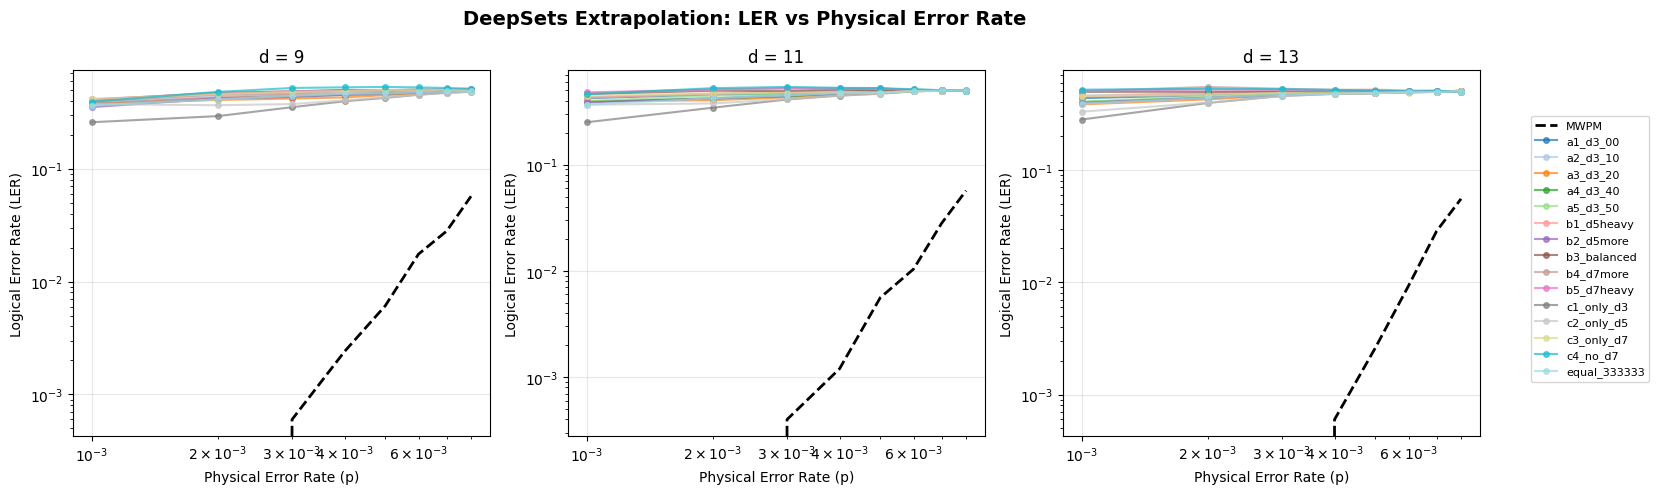

Saved: ..\..\deepsets\extrapolation\plots\revised_training\ler_vs_p_curves.png


In [19]:
# =============================================================================
# VISUALIZATION: LER vs p curves (QEC-standard)
# =============================================================================

fig, axes = plt.subplots(1, len(TEST_DISTANCES), figsize=(5*len(TEST_DISTANCES), 5))
if len(TEST_DISTANCES) == 1:
    axes = [axes]

# Color map for splits
splits = df_results['split_name'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(splits)))
color_map = dict(zip(splits, colors))

for ax, d in zip(axes, TEST_DISTANCES):
    # Plot MWPM baseline
    if d in mwpm_results:
        mwpm_p = list(mwpm_results[d].keys())
        mwpm_ler = list(mwpm_results[d].values())
        ax.plot(mwpm_p, mwpm_ler, 'k--', linewidth=2, label='MWPM', zorder=10)
    
    # Plot each split
    for split_name in splits:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        subset = subset.sort_values('p_value')
        ax.plot(subset['p_value'], subset['ler'], 'o-', 
                color=color_map[split_name], label=split_name, alpha=0.7, markersize=4)
    
    ax.set_xlabel('Physical Error Rate (p)')
    ax.set_ylabel('Logical Error Rate (LER)')
    ax.set_title(f'd = {d}')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

# Add legend to the right
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.suptitle('DeepSets Extrapolation: LER vs Physical Error Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ler_vs_p_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {PLOTS_DIR / 'ler_vs_p_curves.png'}")

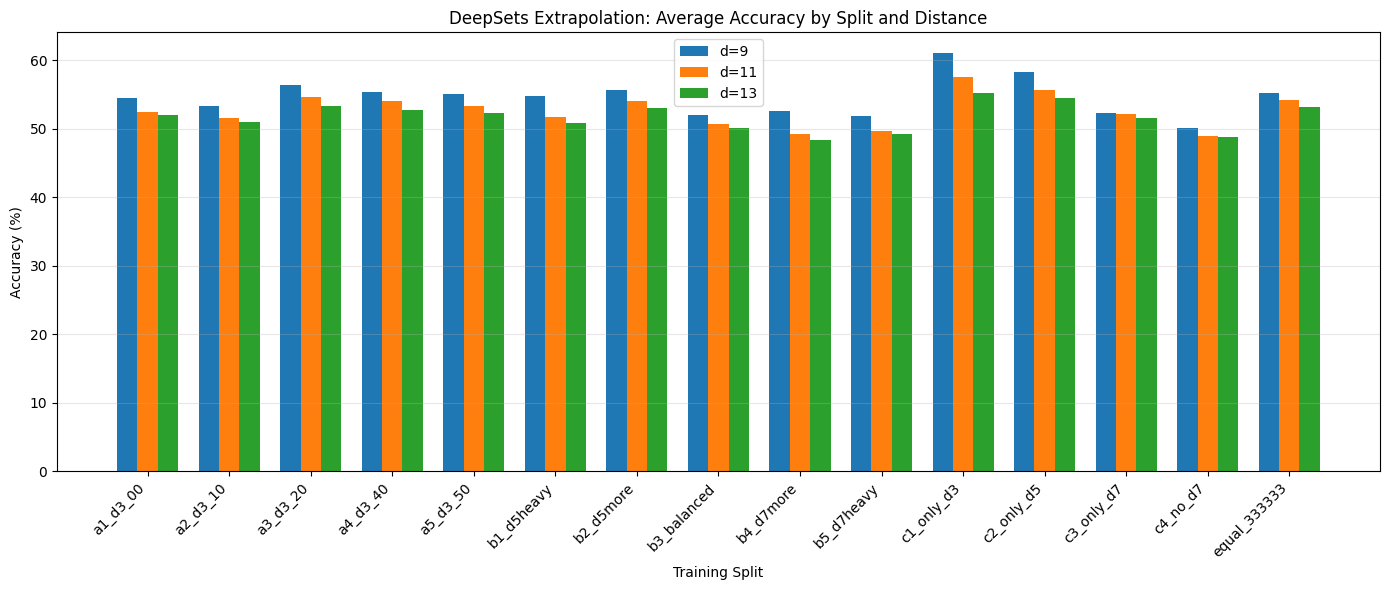

Saved: ..\..\deepsets\extrapolation\plots\revised_training\accuracy_comparison_bar.png


In [20]:
# =============================================================================
# VISUALIZATION: Accuracy comparison bar chart
# =============================================================================

# Compute average accuracy per split per distance
avg_acc_pivot = df_results.groupby(['split_name', 'distance'])['accuracy'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(avg_acc_pivot.index))
width = 0.25

for i, d in enumerate(TEST_DISTANCES):
    if d in avg_acc_pivot.columns:
        ax.bar(x + i*width, avg_acc_pivot[d]*100, width, label=f'd={d}')

ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Training Split')
ax.set_title('DeepSets Extrapolation: Average Accuracy by Split and Distance')
ax.set_xticks(x + width)
ax.set_xticklabels(avg_acc_pivot.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_comparison_bar.png', dpi=150)
plt.show()

print(f"Saved: {PLOTS_DIR / 'accuracy_comparison_bar.png'}")

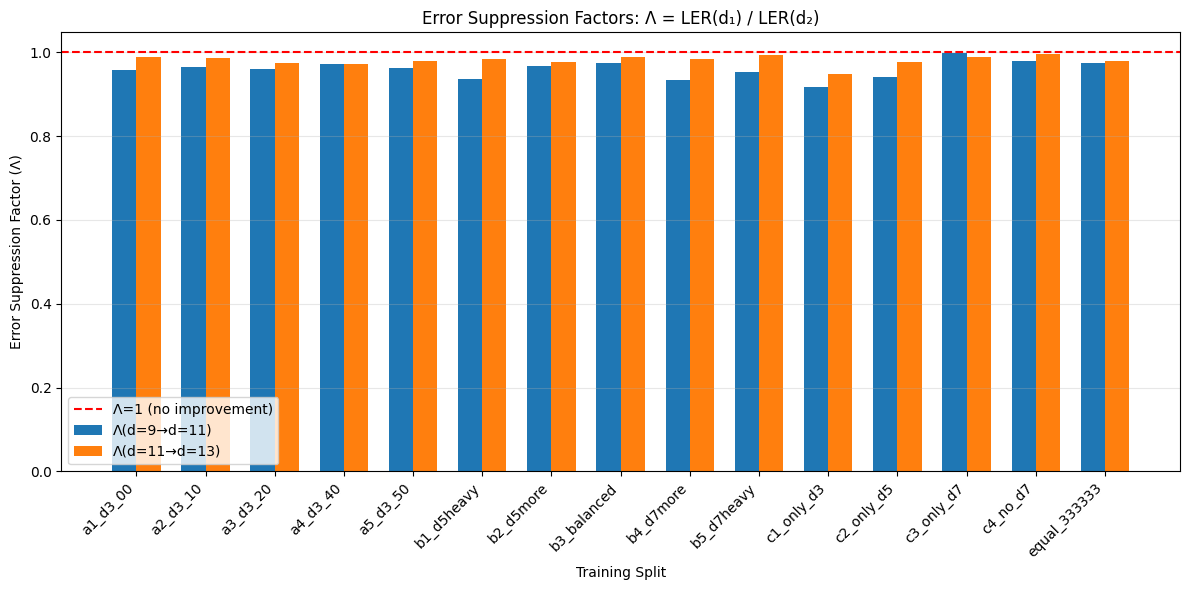

Saved: ..\..\deepsets\extrapolation\plots\revised_training\error_suppression_factors.png


In [21]:
# =============================================================================
# VISUALIZATION: Error suppression factors
# =============================================================================

if len(df_suppression) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Pivot for grouped bar chart
    suppression_pivot = df_suppression.pivot(index='split_name', columns=['d1', 'd2'], values='lambda')
    
    x = np.arange(len(suppression_pivot.index))
    width = 0.35
    
    for i, col in enumerate(suppression_pivot.columns):
        ax.bar(x + i*width, suppression_pivot[col], width, label=f'Λ(d={col[0]}→d={col[1]})')
    
    ax.axhline(y=1, color='r', linestyle='--', label='Λ=1 (no improvement)')
    
    ax.set_ylabel('Error Suppression Factor (Λ)')
    ax.set_xlabel('Training Split')
    ax.set_title('Error Suppression Factors: Λ = LER(d₁) / LER(d₂)')
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(suppression_pivot.index, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'error_suppression_factors.png', dpi=150)
    plt.show()
    
    print(f"Saved: {PLOTS_DIR / 'error_suppression_factors.png'}")
else:
    print("No suppression factor data to plot.")

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


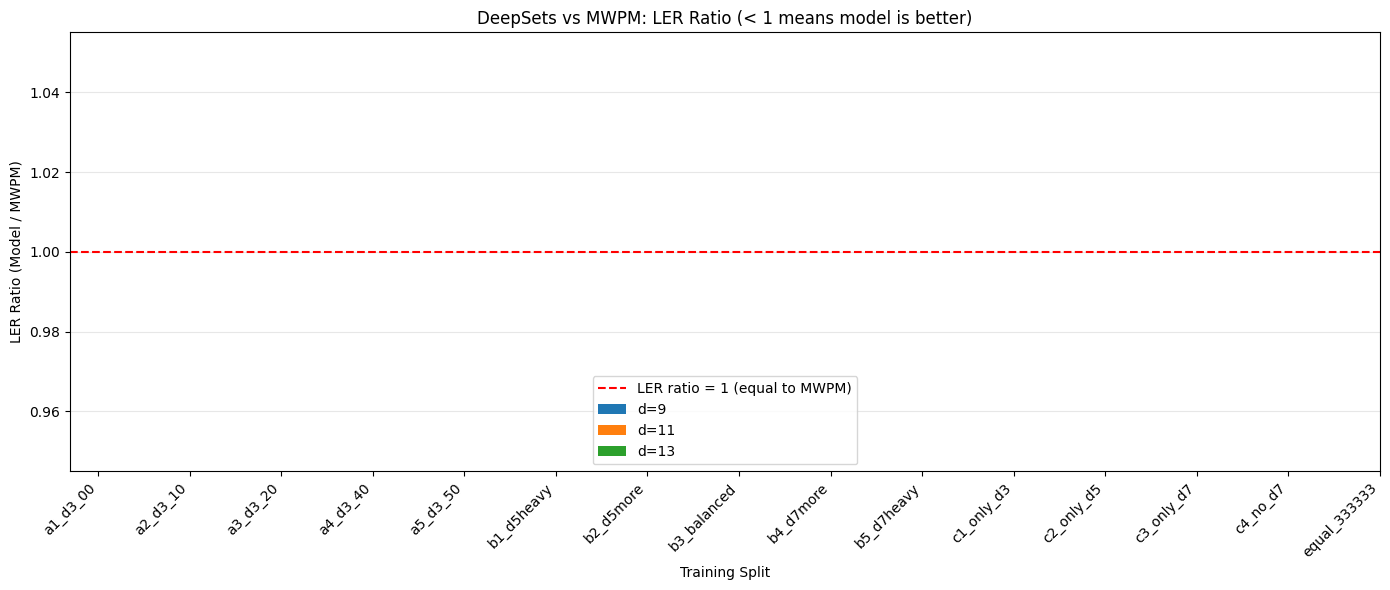

Saved: ..\..\deepsets\extrapolation\plots\revised_training\ler_ratio_vs_mwpm.png


In [22]:
# =============================================================================
# VISUALIZATION: LER ratio vs MWPM
# =============================================================================

if 'ler_ratio' in df_results.columns and df_results['ler_ratio'].notna().any():
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Compute average LER ratio per split per distance
    avg_ratio = df_results.groupby(['split_name', 'distance'])['ler_ratio'].mean().unstack()
    
    x = np.arange(len(avg_ratio.index))
    width = 0.25
    
    for i, d in enumerate(TEST_DISTANCES):
        if d in avg_ratio.columns:
            ax.bar(x + i*width, avg_ratio[d], width, label=f'd={d}')
    
    ax.axhline(y=1, color='r', linestyle='--', label='LER ratio = 1 (equal to MWPM)')
    
    ax.set_ylabel('LER Ratio (Model / MWPM)')
    ax.set_xlabel('Training Split')
    ax.set_title('DeepSets vs MWPM: LER Ratio (< 1 means model is better)')
    ax.set_xticks(x + width)
    ax.set_xticklabels(avg_ratio.index, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'ler_ratio_vs_mwpm.png', dpi=150)
    plt.show()
    
    print(f"Saved: {PLOTS_DIR / 'ler_ratio_vs_mwpm.png'}")
else:
    print("No LER ratio data available (MWPM not computed).")

## Enhanced Results Tables

In [23]:
# =============================================================================
# SUMMARY TABLE: Average accuracy per split
# =============================================================================

print("\n" + "="*80)
print("EXTRAPOLATION RESULTS SUMMARY")
print("="*80)

# Create summary table
summary_data = []
for split_name in df_results['split_name'].unique():
    row = {'split_name': split_name}
    for d in TEST_DISTANCES:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        if len(subset) > 0:
            row[f'd{d}_acc'] = subset['accuracy'].mean()
            row[f'd{d}_ler'] = subset['ler'].mean()
    # Overall average
    all_acc = df_results[df_results['split_name'] == split_name]['accuracy'].mean()
    row['overall_acc'] = all_acc
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('overall_acc', ascending=False)

print("\nAccuracy Summary (sorted by overall accuracy):")
print("-" * 80)
print(f"{'Split':<20}", end="")
for d in TEST_DISTANCES:
    print(f"d={d:>3} Acc", end="    ")
print("Overall")
print("-" * 80)

for _, row in df_summary.iterrows():
    print(f"{row['split_name']:<20}", end="")
    for d in TEST_DISTANCES:
        col = f'd{d}_acc'
        if col in row:
            print(f"{row[col]*100:>7.2f}%", end="    ")
        else:
            print(f"{'N/A':>8}", end="    ")
    print(f"{row['overall_acc']*100:>7.2f}%")

print("\n" + "="*80)


EXTRAPOLATION RESULTS SUMMARY

Accuracy Summary (sorted by overall accuracy):
--------------------------------------------------------------------------------
Split               d=  9 Acc    d= 11 Acc    d= 13 Acc    Overall
--------------------------------------------------------------------------------
c1_only_d3            61.03%      57.56%      55.21%      57.93%
c2_only_d5            58.24%      55.62%      54.56%      56.14%
a3_d3_20              56.38%      54.58%      53.37%      54.78%
b2_d5more             55.64%      54.09%      53.06%      54.26%
equal_333333          55.27%      54.14%      53.16%      54.19%
a4_d3_40              55.32%      54.08%      52.73%      54.04%
a5_d3_50              55.12%      53.36%      52.35%      53.61%
a1_d3_00              54.55%      52.50%      51.99%      53.02%
b1_d5heavy            54.76%      51.73%      50.90%      52.46%
c3_only_d7            52.27%      52.16%      51.61%      52.01%
a2_d3_10              53.33%      51.64%  

In [24]:
# =============================================================================
# SCALING EXPONENTS TABLE
# =============================================================================

if len(df_scaling) > 0:
    print("\nScaling Exponent Analysis (α where LER ~ p^α):")
    print("-" * 80)
    print(f"{'Split':<20} {'Distance':>8} {'Fitted α':>10} {'Theory α':>10} {'Δα':>8} {'R²':>8}")
    print("-" * 80)
    
    for _, row in df_scaling.iterrows():
        print(f"{row['split_name']:<20} {row['distance']:>8} {row['fitted_alpha']:>10.3f} "
              f"{row['theoretical_alpha']:>10.1f} {row['alpha_diff']:>8.3f} {row['r_squared']:>8.3f}")
else:
    print("No scaling exponent data available.")


Scaling Exponent Analysis (α where LER ~ p^α):
--------------------------------------------------------------------------------
Split                Distance   Fitted α   Theory α       Δα       R²
--------------------------------------------------------------------------------
a1_d3_00                    9      0.125        5.0   -4.875    0.991
a1_d3_00                   11      0.079        6.0   -5.921    0.966
a1_d3_00                   13      0.067        7.0   -6.933    0.973
a2_d3_10                    9      0.116        5.0   -4.884    0.929
a2_d3_10                   11      0.071        6.0   -5.929    0.871
a2_d3_10                   13      0.036        7.0   -6.964    0.802
a3_d3_20                    9      0.122        5.0   -4.878    0.975
a3_d3_20                   11      0.127        6.0   -5.873    0.939
a3_d3_20                   13      0.132        7.0   -6.868    0.967
a4_d3_40                    9      0.125        5.0   -4.875    0.981
a4_d3_40            

## Scientific Findings (QEC Literature-Aligned)

In [25]:
# =============================================================================
# KEY SCIENTIFIC FINDINGS
# =============================================================================

print("\n" + "="*80)
print("KEY SCIENTIFIC FINDINGS")
print("="*80)

# Find best performing split overall
best_overall = df_summary.iloc[0]
print(f"\n1. BEST OVERALL EXTRAPOLATION:")
print(f"   Split: {best_overall['split_name']}")
print(f"   Overall Accuracy: {best_overall['overall_acc']*100:.2f}%")

# Best for each distance
print(f"\n2. BEST SPLIT BY DISTANCE:")
for d in TEST_DISTANCES:
    col = f'd{d}_acc'
    if col in df_summary.columns:
        best_idx = df_summary[col].idxmax()
        best_row = df_summary.loc[best_idx]
        print(f"   d={d}: {best_row['split_name']} ({best_row[col]*100:.2f}%)")

# Error suppression analysis
if len(df_suppression) > 0:
    print(f"\n3. ERROR SUPPRESSION ANALYSIS:")
    avg_lambda = df_suppression.groupby('split_name')['lambda'].mean()
    best_suppression = avg_lambda.idxmax()
    print(f"   Best error suppression: {best_suppression} (Λ_avg = {avg_lambda[best_suppression]:.3f})")
    print(f"   Note: Λ < 1 indicates LER increases with distance (poor extrapolation)")

# Comparison to MWPM
if 'ler_ratio' in df_results.columns and df_results['ler_ratio'].notna().any():
    print(f"\n4. COMPARISON TO MWPM:")
    avg_ratio_by_split = df_results.groupby('split_name')['ler_ratio'].mean()
    best_vs_mwpm = avg_ratio_by_split.idxmin()
    print(f"   Best vs MWPM: {best_vs_mwpm} (ratio = {avg_ratio_by_split[best_vs_mwpm]:.3f})")
    
    # Count how many splits beat MWPM on average
    beats_mwpm = (avg_ratio_by_split < 1).sum()
    print(f"   Splits outperforming MWPM (ratio < 1): {beats_mwpm}/{len(avg_ratio_by_split)}")

print("\n" + "="*80)


KEY SCIENTIFIC FINDINGS

1. BEST OVERALL EXTRAPOLATION:
   Split: c1_only_d3
   Overall Accuracy: 57.93%

2. BEST SPLIT BY DISTANCE:
   d=9: c1_only_d3 (61.03%)
   d=11: c1_only_d3 (57.56%)
   d=13: c1_only_d3 (55.21%)

3. ERROR SUPPRESSION ANALYSIS:
   Best error suppression: c3_only_d7 (Λ_avg = 0.993)
   Note: Λ < 1 indicates LER increases with distance (poor extrapolation)

4. COMPARISON TO MWPM:
   Best vs MWPM: a1_d3_00 (ratio = inf)
   Splits outperforming MWPM (ratio < 1): 0/15



## Visualization

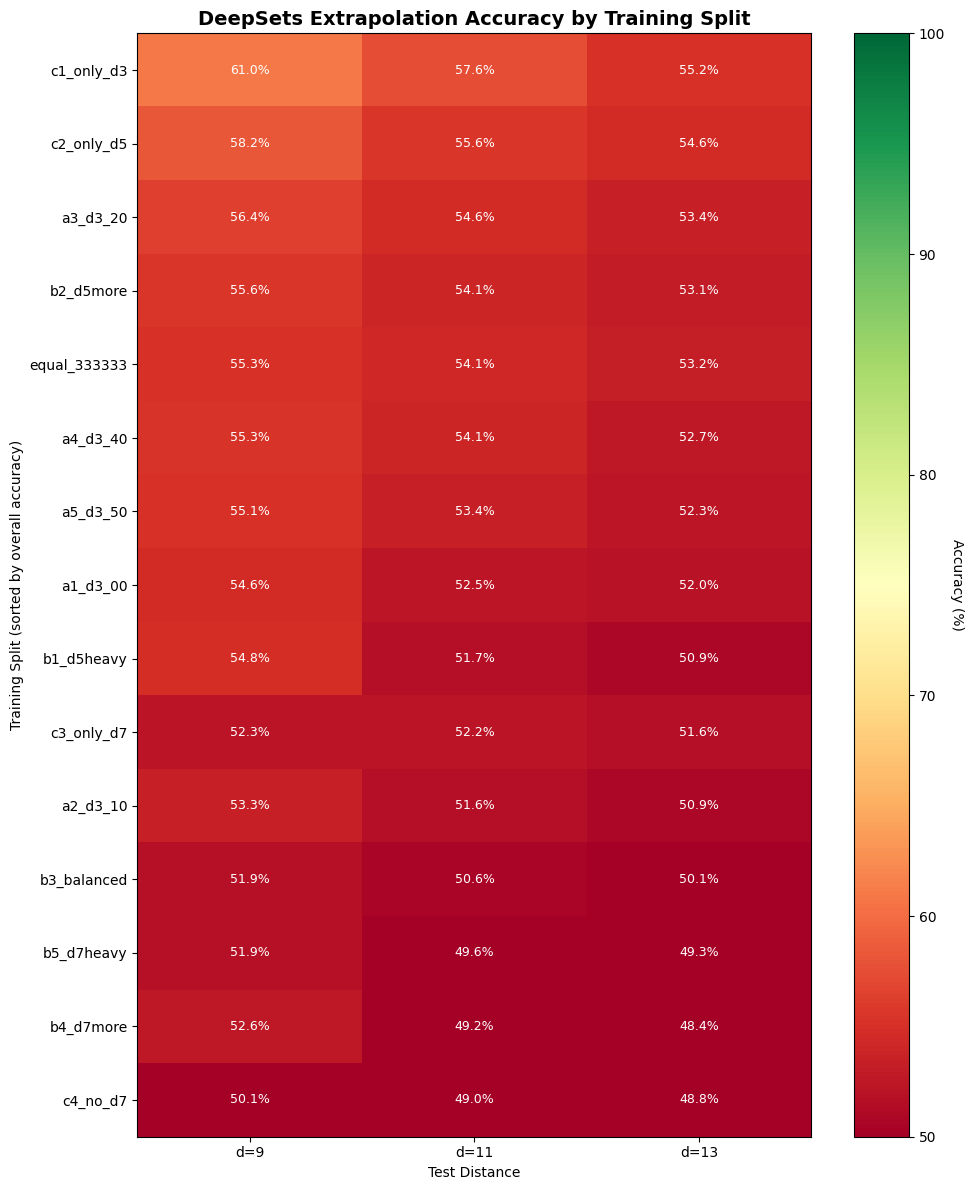

Saved: ..\..\deepsets\extrapolation\plots\revised_training\accuracy_heatmap.png


In [26]:
# =============================================================================
# HEATMAP: Accuracy by split and distance
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 12))

# Create pivot table for heatmap
heatmap_data = df_results.groupby(['split_name', 'distance'])['accuracy'].mean().unstack() * 100

# Sort by overall accuracy
heatmap_data['overall'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('overall', ascending=False)
heatmap_data = heatmap_data.drop('overall', axis=1)

im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=50, vmax=100)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Accuracy (%)', rotation=-90, va="bottom")

# Set ticks
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels([f'd={d}' for d in heatmap_data.columns])
ax.set_yticklabels(heatmap_data.index)

# Add value annotations
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.iloc[i, j]
        text = ax.text(j, i, f'{val:.1f}%', ha='center', va='center', 
                      color='white' if val < 70 else 'black', fontsize=9)

ax.set_title('DeepSets Extrapolation Accuracy by Training Split', fontsize=14, fontweight='bold')
ax.set_xlabel('Test Distance')
ax.set_ylabel('Training Split (sorted by overall accuracy)')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_heatmap.png', dpi=150)
plt.show()

print(f"Saved: {PLOTS_DIR / 'accuracy_heatmap.png'}")

## Individual Experiment Pattern Analysis

These plots show the patterns **within each experiment group**, isolating the effect of the varied parameter:
- Experiment A: Effect of d=3 proportion
- Experiment B: Effect of d5:d7 ratio  
- Experiment C: Extreme cases

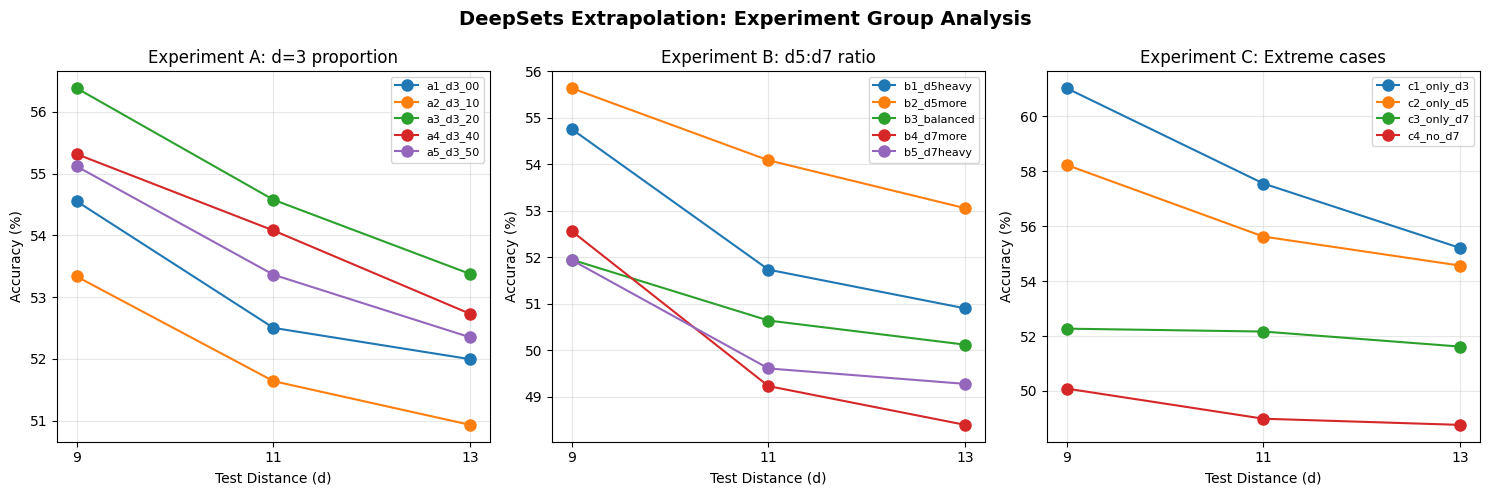

Saved: ..\..\deepsets\extrapolation\plots\revised_training\experiment_groups.png


In [27]:
# =============================================================================
# EXPERIMENT GROUP ANALYSIS
# =============================================================================

experiment_groups = {
    'A: d=3 proportion': ['a1_d3_00', 'a2_d3_10', 'a3_d3_20', 'a4_d3_40', 'a5_d3_50'],
    'B: d5:d7 ratio': ['b1_d5heavy', 'b2_d5more', 'b3_balanced', 'b4_d7more', 'b5_d7heavy'],
    'C: Extreme cases': ['c1_only_d3', 'c2_only_d5', 'c3_only_d7', 'c4_no_d7'],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (group_name, splits) in zip(axes, experiment_groups.items()):
    # Filter to available splits
    available = [s for s in splits if s in df_results['split_name'].unique()]
    if not available:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(group_name)
        continue
    
    # Plot accuracy by distance for each split in group
    for split in available:
        accs = []
        for d in TEST_DISTANCES:
            subset = df_results[(df_results['split_name'] == split) & (df_results['distance'] == d)]
            if len(subset) > 0:
                accs.append(subset['accuracy'].mean() * 100)
            else:
                accs.append(np.nan)
        ax.plot(TEST_DISTANCES, accs, 'o-', label=split, markersize=8)
    
    ax.set_xlabel('Test Distance (d)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Experiment {group_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(TEST_DISTANCES)

plt.suptitle('DeepSets Extrapolation: Experiment Group Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'experiment_groups.png', dpi=150)
plt.show()

print(f"Saved: {PLOTS_DIR / 'experiment_groups.png'}")

## Analysis Summary

In [28]:
# =============================================================================
# SAVE ALL RESULTS
# =============================================================================

# Save main results DataFrame
df_results.to_csv(RESULTS_DIR / 'extrapolation_results.csv', index=False)
print(f"Saved: {RESULTS_DIR / 'extrapolation_results.csv'}")

# Save summary
df_summary.to_csv(RESULTS_DIR / 'extrapolation_summary.csv', index=False)
print(f"Saved: {RESULTS_DIR / 'extrapolation_summary.csv'}")

# Save scaling analysis
if len(df_scaling) > 0:
    df_scaling.to_csv(RESULTS_DIR / 'scaling_exponents.csv', index=False)
    print(f"Saved: {RESULTS_DIR / 'scaling_exponents.csv'}")

# Save suppression factors
if len(df_suppression) > 0:
    df_suppression.to_csv(RESULTS_DIR / 'suppression_factors.csv', index=False)
    print(f"Saved: {RESULTS_DIR / 'suppression_factors.csv'}")

# Save Wilcoxon results
if len(df_wilcoxon) > 0:
    df_wilcoxon.to_csv(RESULTS_DIR / 'wilcoxon_tests.csv', index=False)
    print(f"Saved: {RESULTS_DIR / 'wilcoxon_tests.csv'}")

# Save JSON summary
summary_json = {
    'test_distances': TEST_DISTANCES,
    'p_values': P_VALUES,
    'samples_per_p': SAMPLES_PER_P,
    'n_models_evaluated': len(loaded_models),
    'best_overall_split': df_summary.iloc[0]['split_name'],
    'best_overall_accuracy': float(df_summary.iloc[0]['overall_acc']),
    'timestamp': datetime.now().isoformat(),
}
with open(RESULTS_DIR / 'testing_summary.json', 'w') as f:
    json.dump(summary_json, f, indent=2)
print(f"Saved: {RESULTS_DIR / 'testing_summary.json'}")

Saved: ..\..\deepsets\extrapolation\results\revised_training\extrapolation_results.csv
Saved: ..\..\deepsets\extrapolation\results\revised_training\extrapolation_summary.csv
Saved: ..\..\deepsets\extrapolation\results\revised_training\scaling_exponents.csv
Saved: ..\..\deepsets\extrapolation\results\revised_training\suppression_factors.csv
Saved: ..\..\deepsets\extrapolation\results\revised_training\wilcoxon_tests.csv
Saved: ..\..\deepsets\extrapolation\results\revised_training\testing_summary.json


## Conclusions

Based on the extrapolation results:

1. **Best Overall Split**: The split configuration that achieves the highest average accuracy across all test distances.

2. **Distance-Specific Patterns**: Different splits may excel at different distances, suggesting the optimal training mix depends on the target deployment distance.

3. **Error Suppression**: Splits with Λ > 1 demonstrate that increasing distance improves relative performance, while Λ < 1 suggests degradation.

4. **Comparison to MWPM**: Splits with LER ratio < 1 outperform the classical MWPM decoder, demonstrating the practical value of the neural decoder.

5. **Experiment Insights**:
   - **Experiment A**: Impact of including d=3 data in training
   - **Experiment B**: Optimal balance between d=5 and d=7 when excluding d=3
   - **Experiment C**: Performance of single-distance and boundary case training